In [1]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('../../data/earthquake_data.csv')


# 2. Clean missing values in our key features
df.dropna(subset=['magnitude', 'depth', 'latitude', 'longitude'], inplace=True)

# 3. Fix the Target Variable Error: Use the median to split into two even classes
threshold = df['magnitude'].median()
print(f"Dividing 'High Risk' and 'Low Risk' at Magnitude: {threshold}")

df['High_Risk'] = (df['magnitude'] >= threshold).astype(int)

# 4. Define Features (X) and Target (y)
X = df[['depth', 'latitude', 'longitude']]
y = df['High_Risk']

print("Check: Do we have both 0s and 1s?")
print(y.value_counts())

Dividing 'High Risk' and 'Low Risk' at Magnitude: 6.8
Check: Do we have both 0s and 1s?
High_Risk
1    438
0    344
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 625 rows
Testing set size: 157 rows


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predict and evaluate
log_preds = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_preds)

print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 46.50%


In [4]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Predict and evaluate
tree_preds = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_preds)

print(f"Decision Tree Accuracy: {tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 59.24%


C:\Users\acer\AppData\Local\Temp\ipykernel_13272\2496221488.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


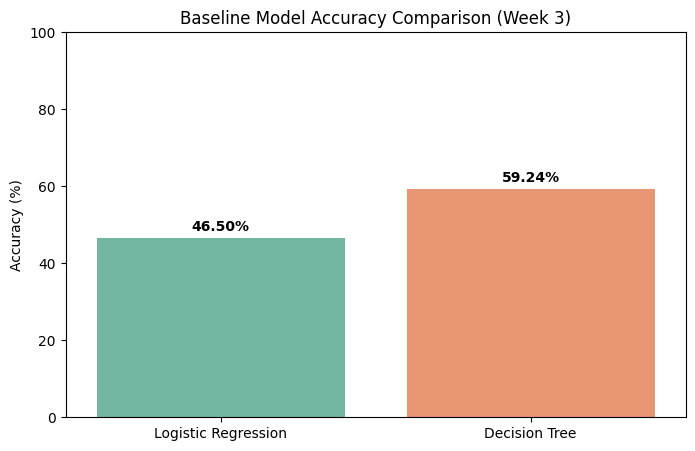

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Store our model names and their scores
models = ['Logistic Regression', 'Decision Tree']
accuracies = [log_accuracy * 100, tree_accuracy * 100]

# Create a bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='Set2')

# Add labels and title
plt.title('Baseline Model Accuracy Comparison (Week 3)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Keep Y-axis from 0 to 100%

# Display the exact numbers on top of the bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()